In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler,OneHotEncoder,OrdinalEncoder
from sklearn.linear_model import LinearRegression,Ridge,Lasso,ElasticNet
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score,mean_absolute_percentage_error
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV,train_test_split
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from scipy.stats import ttest_ind
from scipy import stats
from scipy.stats import chisquare
from scipy.stats import chi2_contingency
from sklearn.pipeline import Pipeline
import math
from scipy import stats
import os
import joblib

In [3]:
df = pd.read_csv(r'concert_dataset_cleaned.csv')

In [4]:
df.head()

,artist,artist_country,record_label,artist_age,primary_genre,secondary_genre,multi_genre_artist,spotify_popularity,followers_millions,monthly_listeners_millions,...,advertising_revenue_usd,attendance,sellout_pct,occupancy_pct,avg_spend_per_customer_usd,total_revenue_usd,profit_usd,average_ticket_price_usd,competing_concerts_same_city_week,Covid
0,Boygenius,USA,Not Available,27.0,Alternative Pop,Indie Rock,Yes,19,4.4,3.2,...,18736.29,3804,53.5,53.5,63.65,502614.84,190337.59,93.39,1,Pre-Covid
1,Bonobo,Not Available,Independent,NaN,EDM,Downtempo,Yes,60,13.7,12.6,...,241142.19,81447,100.0,100.0,89.10,22853464.95,6555703.52,249.68,1,Post-Covid
2,Robin Schulz,Germany,Not Available,35.0,EDM,Tropical House,Yes,53,10.3,7.9,...,41682.27,62954,91.2,86.1,114.95,12300605.62,4008260.29,170.00,4,Post-Covid
3,Morgan Wallen,USA,Universal,26.0,Country,Country Pop,Yes,40,14.1,8.4,...,9081.63,10240,65.9,61.6,73.57,1814949.72,604707.96,144.85,1,Pre-Covid
4,Gorgon City,UK,Not Available,41.0,EDM,House,Yes,35,2.8,1.9,...,143508.01,25979,32.8,30.8,50.66,3166126.70,1289886.74,69.10,0,Post-Covid


In [5]:
df.shape

(20000, 70)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 70 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   artist                             20000 non-null  object 
 1   artist_country                     20000 non-null  object 
 2   record_label                       20000 non-null  object 
 3   artist_age                         15283 non-null  float64
 4   primary_genre                      20000 non-null  object 
 5   secondary_genre                    20000 non-null  object 
 6   multi_genre_artist                 20000 non-null  object 
 7   spotify_popularity                 20000 non-null  int64  
 8   followers_millions                 20000 non-null  float64
 9   monthly_listeners_millions         20000 non-null  float64
 10  total_streams_billions             20000 non-null  float64
 11  years_active                       20000 non-null  int

In [7]:
df.describe()

,artist_age,spotify_popularity,followers_millions,monthly_listeners_millions,total_streams_billions,years_active,grammy_winner,instagram_followers_millions,tiktok_followers_millions,youtube_subscribers_millions,...,sponsor_revenue_usd,advertising_revenue_usd,attendance,sellout_pct,occupancy_pct,avg_spend_per_customer_usd,total_revenue_usd,profit_usd,average_ticket_price_usd,competing_concerts_same_city_week
count,15283.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,...,2.000000e+04,20000.000000,20000.00000,20000.000000,20000.000000,20000.000000,2.000000e+04,2.000000e+04,20000.000000,20000.000000
mean,34.126415,46.083050,11.261200,8.166535,1.994875,9.031050,0.181600,10.785300,11.127395,9.534725,...,2.027402e+05,70905.521917,25900.52630,57.588490,57.634235,78.121243,5.267523e+06,1.717689e+06,146.359656,1.236900
std,9.086303,21.873543,8.468808,6.417774,1.652014,4.498688,0.385524,8.498068,9.491449,7.673140,...,2.651795e+05,96649.083758,30452.95422,21.663408,21.510449,35.579315,7.452705e+06,2.519111e+06,64.244155,1.608542
min,12.000000,15.000000,0.200000,0.100000,0.050000,1.000000,0.000000,0.200000,0.100000,0.100000,...,0.000000e+00,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,13.600000,0.000000
25%,28.000000,28.000000,4.700000,3.300000,0.780000,6.000000,0.000000,4.500000,4.300000,3.900000,...,2.583177e+04,8629.875000,4009.50000,44.500000,44.700000,55.190000,6.162072e+05,1.922473e+05,98.325000,0.000000
50%,33.000000,43.000000,9.100000,6.500000,1.530000,9.000000,0.000000,8.400000,8.250000,7.400000,...,9.126029e+04,31169.990000,12486.50000,58.300000,58.400000,74.140000,2.258633e+06,7.093491e+05,136.855000,1.000000
75%,39.000000,61.000000,15.300000,11.100000,2.710000,12.000000,0.000000,15.000000,14.900000,12.700000,...,2.783379e+05,94802.402500,39839.00000,72.400000,72.300000,98.022500,6.864112e+06,2.195439e+06,184.662500,2.000000
max,64.000000,100.000000,44.900000,37.200000,11.070000,22.000000,1.000000,55.700000,66.600000,46.400000,...,1.793797e+06,845544.230000,180000.00000,100.000000,100.000000,255.990000,7.408455e+07,2.733568e+07,470.060000,11.000000


In [8]:
df.columns.tolist()

['artist',
 'artist_country',
 'record_label',
 'artist_age',
 'primary_genre',
 'secondary_genre',
 'multi_genre_artist',
 'spotify_popularity',
 'followers_millions',
 'monthly_listeners_millions',
 'total_streams_billions',
 'years_active',
 'grammy_winner',
 'instagram_followers_millions',
 'tiktok_followers_millions',
 'youtube_subscribers_millions',
 'twitter_followers_millions',
 'facebook_followers_millions',
 'google_trend_index',
 'event_type',
 'event_status',
 'festival_name',
 'festival_tier',
 'num_artists_on_lineup',
 'is_headliner',
 'billing_status',
 'is_sub_headliner',
 'venue_name',
 'venue_type',
 'city',
 'country',
 'capacity',
 'distance_from_airport_km',
 'date',
 'day_of_week',
 'month',
 'quarter',
 'year',
 'is_weekend',
 'is_holiday',
 'peak_season',
 'temperature_c',
 'humidity_pct',
 'rainfall_mm',
 'wind_kmh',
 'cloud_cover_pct',
 'weather_type',
 'heat_index',
 'feels_like_c',
 'uv_index',
 'early_bird_price_usd',
 'ga_price_usd',
 'vip_price_usd',
 'vv

In [9]:
#removing the output feature leaking & unused columns before encoding and model training
new_df = df.drop(['early_bird_price_usd','ga_price_usd','vip_price_usd',
                  'vvip_price_usd','dynamic_price_factor','merchandise_revenue_usd','parking_revenue_usd',
                  'food_revenue_usd','bar_revenue_usd','sponsor_revenue_usd','advertising_revenue_usd',
                  'avg_spend_per_customer_usd','total_revenue_usd','profit_usd','date','attendance','sellout_pct',
                  'occupancy_pct','artist_age','temperature_c','humidity_pct','rainfall_mm','wind_kmh','cloud_cover_pct',
                  'heat_index','feels_like_c','uv_index'],axis=1)

In [10]:
new_df.shape

(20000, 43)

In [11]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 43 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   artist                             20000 non-null  object 
 1   artist_country                     20000 non-null  object 
 2   record_label                       20000 non-null  object 
 3   primary_genre                      20000 non-null  object 
 4   secondary_genre                    20000 non-null  object 
 5   multi_genre_artist                 20000 non-null  object 
 6   spotify_popularity                 20000 non-null  int64  
 7   followers_millions                 20000 non-null  float64
 8   monthly_listeners_millions         20000 non-null  float64
 9   total_streams_billions             20000 non-null  float64
 10  years_active                       20000 non-null  int64  
 11  grammy_winner                      20000 non-null  int

In [12]:
#Printing the cardinality of all categorical columns.
new_df.select_dtypes(include='object').nunique().sort_values(ascending=False)

venue_name            651
artist                216
festival_name         113
city                   73
secondary_genre        71
country                29
artist_country         24
primary_genre          13
venue_type              9
day_of_week             7
weather_type            6
record_label            5
event_type              4
billing_status          4
Covid                   3
is_headliner            2
event_status            2
multi_genre_artist      2
is_sub_headliner        2
dtype: int64

# Data Splitting Strategy

Before applying any encoding or feature transformation, the dataset was divided into training (70%) and testing (30%) sets using train_test_split().

Why was the data split before encoding?

Certain preprocessing techniques such as Frequency Encoding, One-Hot Encoding, and Feature Scaling learn patterns from the data. Performing these transformations on the entire dataset before splitting would introduce data leakage, allowing information from the test set to influence the training process.

To prevent this:

All preprocessing steps were fit only on the training dataset.
The learned transformations were then applied to both the training and testing datasets.
This approach ensures that the model is evaluated on completely unseen data, closely simulating real-world deployment.

# Note: 
The same artist may appear in both the training and testing datasets through different concerts, venues, cities, or dates. This is an intentional design choice rather than data leakage. The objective of this project is to estimate ticket prices for future concert events of known artists using their historical popularity, demand, and performance characteristics. Since real-world concert pricing relies on an artist's established track record, allowing artist repetition across train and test reflects the intended deployment scenario rather than introducing unrealistic information into the model.

# Future Extension: 
If the objective were to evaluate the model's ability to generalize to completely unseen artists, a group-based split (e.g., GroupShuffleSplit using artist as the grouping variable) would be a more appropriate evaluation strategy.

# Encoding Strategy

Since the dataset contains categorical variables with varying levels of cardinality, different encoding techniques were selected based on the number of unique categories and their suitability for machine learning models.

# Frequency Encoding (High Cardinality Features)

Frequency Encoding was applied to categorical variables containing a large number of unique categories. Instead of creating hundreds of dummy variables, each category was replaced with its occurrence frequency calculated only from the training dataset.

The same frequency mapping was subsequently applied to the test dataset. Categories not present in the training data were assigned a frequency value of 0.
| Feature           | Cardinality |
| ----------------- | ----------: |
| `venue_name`      |         651 |
| `artist`          |         216 |
| `festival_name`   |         113 |
| `city`            |          73 |
| `secondary_genre` |          71 |
| `country`         |          29 |
| `artist_country`  |          24 |

# One-Hot Encoding (Nominal Features)

One-Hot Encoding was applied to nominal categorical variables that do not possess any natural ordering.

The encoder was fit only on the training dataset and subsequently used to transform both the training and testing datasets.

To avoid the Dummy Variable Trap and reduce multicollinearity in linear regression models, the first category of each feature was dropped (drop='first').
| Feature          | Cardinality |
| ---------------- | ----------: |
| `primary_genre`  |          13 |
| `day_of_week`    |           7 |
| `weather_type`   |           6 |
| `record_label`   |           5 |
| `event_type`     |           4 |
| `billing_status` |           4 |
| `Covid`          |           3 |

# Binary Encoding

Binary categorical variables were directly mapped to numerical values (0 and 1), eliminating the need for additional dummy variables.
| Feature              | Mapping                 |
| -------------------- | ----------------------- |
| `is_headliner`       | Yes → 1, No → 0         |
| `is_sub_headliner`   | Yes → 1, No → 0         |
| `multi_genre_artist` | Yes → 1, No → 0         |
| `event_status`       | Held → 1, Cancelled → 0 |

# Why this Encoding Strategy?

Frequency Encoding was selected for high-cardinality features to prevent excessive dimensionality while preserving category prevalence.
One-Hot Encoding was used for nominal variables to eliminate artificial ordinal relationships between categories.
Binary Encoding was applied to dichotomous variables to improve computational efficiency without losing information.
All learned transformations (Frequency Encoding, One-Hot Encoding, and later Standard Scaling) were fit exclusively on the training dataset to eliminate data leakage and ensure an unbiased evaluation of model performance.

# Note: 
The preprocessing pipeline was deliberately designed to follow industry best practices by splitting the data before any learned transformations. This ensures that feature engineering, encoding, and scaling do not inadvertently expose the model to information from the test dataset, resulting in a more reliable estimate of real-world predictive performance.

In [13]:
x = new_df.drop('average_ticket_price_usd',axis=1)
y = new_df['average_ticket_price_usd']

In [14]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.30,random_state=42)

In [15]:
artist_freq_map = x_train['artist'].value_counts()
x_train['artist'] = x_train['artist'].map(artist_freq_map)
x_test['artist'] = x_test['artist'].map(artist_freq_map).fillna(0)

In [16]:
artist_country_freq_map = x_train['artist_country'].value_counts()
x_train['artist_country'] = x_train['artist_country'].map(artist_country_freq_map)
x_test['artist_country'] = x_test['artist_country'].map(artist_country_freq_map).fillna(0)

In [17]:
venue_name_freq_map = x_train['venue_name'].value_counts()
x_train['venue_name'] = x_train['venue_name'].map(venue_name_freq_map)
x_test['venue_name'] = x_test['venue_name'].map(venue_name_freq_map).fillna(0)

In [18]:
festival_name_freq_map = x_train['festival_name'].value_counts()
x_train['festival_name'] = x_train['festival_name'].map(festival_name_freq_map)
x_test['festival_name'] = x_test['festival_name'].map(festival_name_freq_map).fillna(0)

In [19]:
city_freq_map = x_train['city'].value_counts()
x_train['city'] = x_train['city'].map(city_freq_map)
x_test['city'] = x_test['city'].map(city_freq_map).fillna(0)

In [20]:
secondary_genre_freq_map = x_train['secondary_genre'].value_counts()
x_train['secondary_genre'] = x_train['secondary_genre'].map(secondary_genre_freq_map)
x_test['secondary_genre'] = x_test['secondary_genre'].map(secondary_genre_freq_map).fillna(0)

In [21]:
country_freq_map = x_train['country'].value_counts()
x_train['country'] = x_train['country'].map(country_freq_map)
x_test['country'] = x_test['country'].map(country_freq_map).fillna(0)

In [22]:
ohe = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)
ohe_columns = ['primary_genre','day_of_week','weather_type','record_label','event_type','billing_status','Covid']
ohe.fit(x_train[ohe_columns])

,categories,'auto'
,drop,'first'
,sparse_output,False
,dtype,<class 'numpy.float64'>
,handle_unknown,'ignore'
,min_frequency,None
,max_categories,None
,feature_name_combiner,'concat'


In [23]:
x_train_ohe = pd.DataFrame(ohe.transform(x_train[ohe_columns]),columns=ohe.get_feature_names_out(ohe_columns),
                           index=x_train.index)

In [24]:
x_test_ohe = pd.DataFrame(ohe.transform(x_test[ohe_columns]),columns=ohe.get_feature_names_out(ohe_columns),
                         index=x_test.index)

In [25]:
x_train = x_train.drop(columns=ohe_columns)
x_test = x_test.drop(columns = ohe_columns)

In [26]:
x_train = pd.concat([x_train,x_train_ohe],axis=1)
x_test = pd.concat([x_test,x_test_ohe],axis=1)

In [27]:
print(x_train.shape)
print(x_test.shape)

(14000, 70)
(6000, 70)


In [28]:
oe = OrdinalEncoder()
x_train[['venue_type']] = oe.fit_transform(x_train[['venue_type']])
x_test[['venue_type']] = oe.transform(x_test[['venue_type']])

In [29]:
x_train['multi_genre_artist'] = x_train['multi_genre_artist'].map({'Yes':1,'No':0})
x_test['multi_genre_artist'] = x_test['multi_genre_artist'].map({'Yes':1,'No':0})
x_train['is_headliner'] = x_train['is_headliner'].map({'Yes':1,'No':0})
x_test['is_headliner'] = x_test['is_headliner'].map({'Yes':1,'No':0})
x_train['is_sub_headliner'] = x_train['is_sub_headliner'].map({'Yes':1,'No':0})
x_test['is_sub_headliner'] = x_test['is_sub_headliner'].map({'Yes':1,'No':0})

In [30]:
x_train['event_status'] = x_train['event_status'].map({'Held':1,'Cancelled':0})
x_test['event_status'] = x_test['event_status'].map({'Held':1,'Cancelled':0})

In [31]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14000 entries, 17218 to 15795
Data columns (total 70 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   artist                             14000 non-null  int64  
 1   artist_country                     14000 non-null  int64  
 2   secondary_genre                    14000 non-null  int64  
 3   multi_genre_artist                 14000 non-null  int64  
 4   spotify_popularity                 14000 non-null  int64  
 5   followers_millions                 14000 non-null  float64
 6   monthly_listeners_millions         14000 non-null  float64
 7   total_streams_billions             14000 non-null  float64
 8   years_active                       14000 non-null  int64  
 9   grammy_winner                      14000 non-null  int64  
 10  instagram_followers_millions       14000 non-null  float64
 11  tiktok_followers_millions          14000 non-null  floa

In [32]:
x_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6000 entries, 10650 to 9165
Data columns (total 70 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   artist                             6000 non-null   int64  
 1   artist_country                     6000 non-null   int64  
 2   secondary_genre                    6000 non-null   int64  
 3   multi_genre_artist                 6000 non-null   int64  
 4   spotify_popularity                 6000 non-null   int64  
 5   followers_millions                 6000 non-null   float64
 6   monthly_listeners_millions         6000 non-null   float64
 7   total_streams_billions             6000 non-null   float64
 8   years_active                       6000 non-null   int64  
 9   grammy_winner                      6000 non-null   int64  
 10  instagram_followers_millions       6000 non-null   float64
 11  tiktok_followers_millions          6000 non-null   float6

# Outliers Analysis and Stastical Checks of Dataset

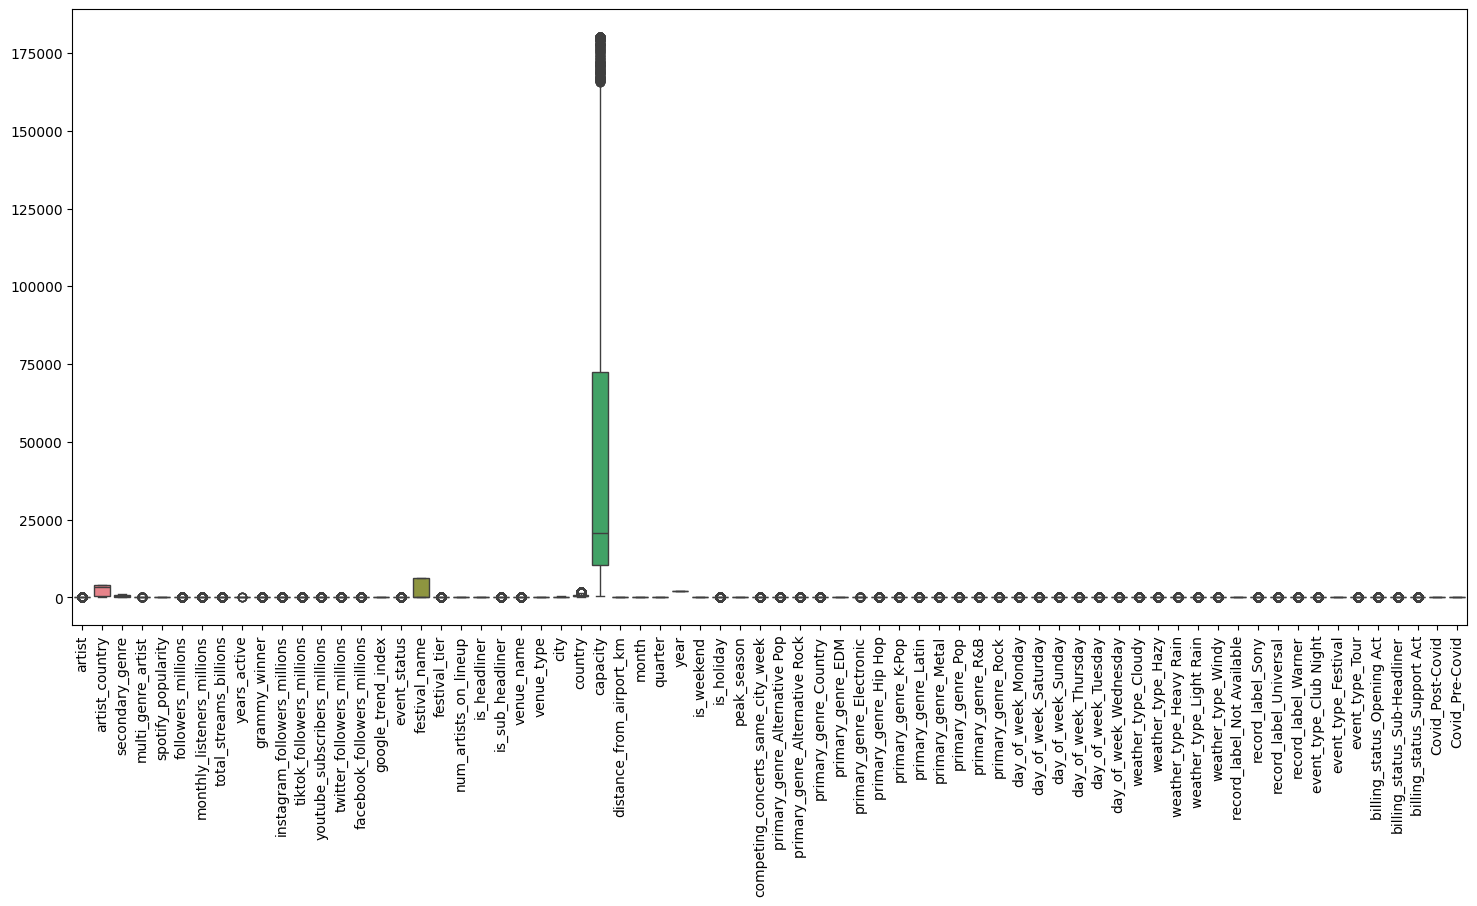

In [33]:
plt.figure(figsize=(18,8))
sns.boxplot(data=x_train)
plt.xticks(rotation=90)
plt.show()

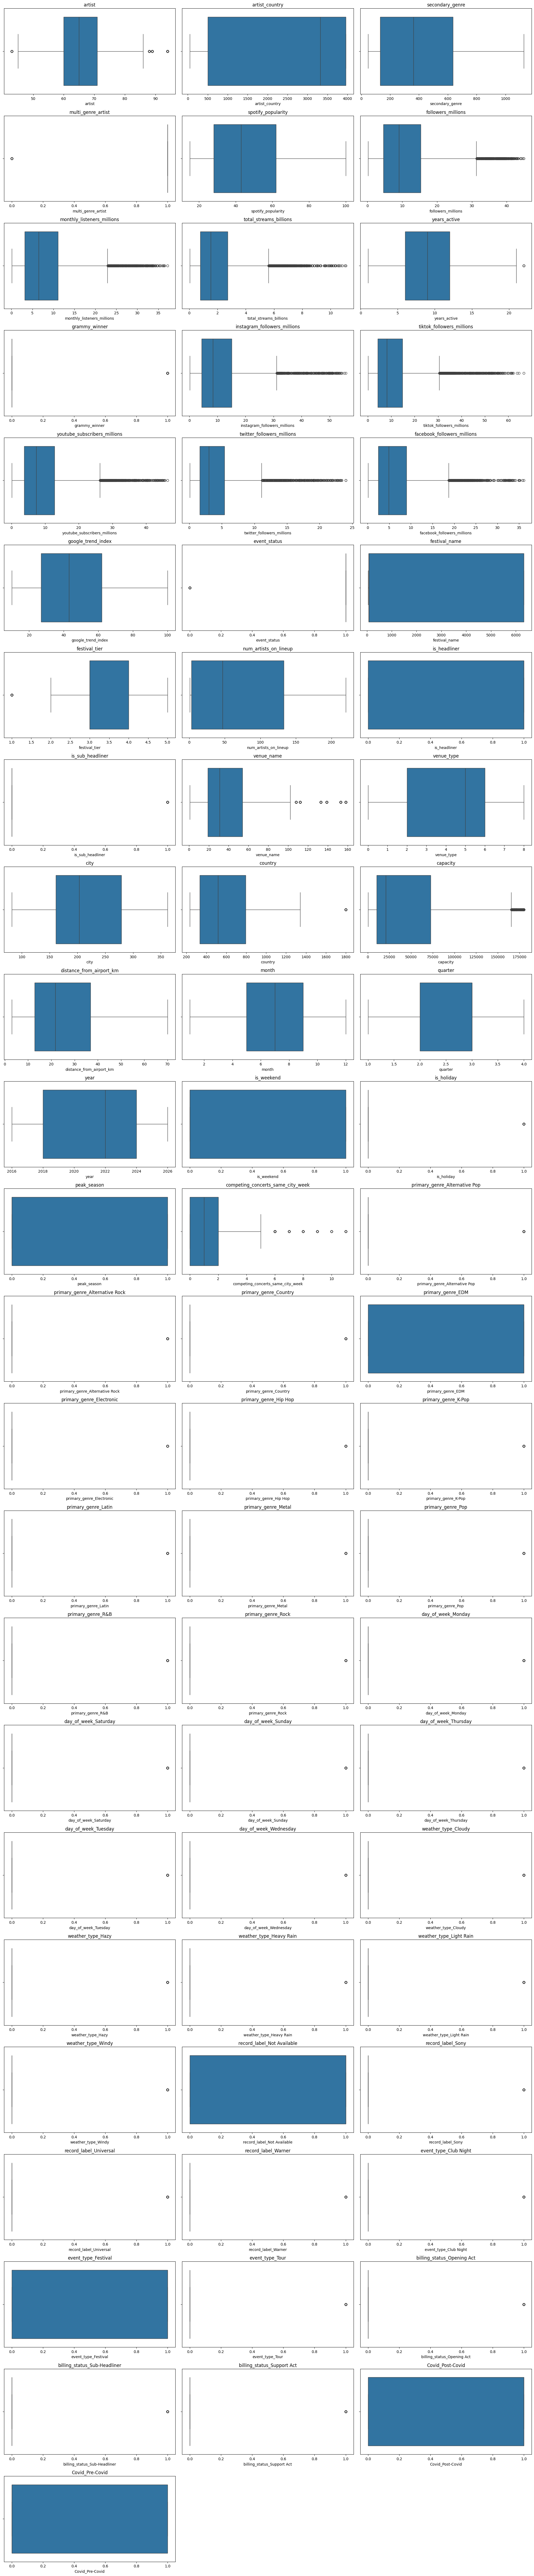

In [34]:
n_cols = 3
n_rows = math.ceil(len(x_train.columns) / n_cols)
plt.figure(figsize=(20, n_rows*4))
for i, col in enumerate(x_train.columns):
    plt.subplot(n_rows, n_cols, i+1)
    sns.boxplot(x=x_train[col])
    plt.title(col)
plt.tight_layout()
plt.show()

# Outlier Analysis - Observations
Boxplots were generated for all numerical features to identify potential outliers. Most of the detected outliers were found in artist popularity metrics (followers, monthly listeners, total streams, and social media followers), venue capacity, and frequency-encoded categorical variables such as venue_name and country.

After evaluating these features from a business perspective, the majority of these observations were retained because they represent genuine real-world variations rather than data quality issues. For example, globally recognized artists naturally have significantly higher popularity metrics, while large stadiums legitimately possess much higher capacities than smaller venues. Similarly, apparent outliers in frequency-encoded features are a consequence of the encoding technique and do not indicate anomalous observations.

The only feature requiring further investigation is competing_concerts_same_city_week, as unusually high values may represent either legitimate periods of high event concentration or potential anomalies that could disproportionately influence the regression model.

In [35]:
x_train['competing_concerts_same_city_week'].describe()

count    14000.000000
mean         1.227714
std          1.585618
min          0.000000
25%          0.000000
50%          1.000000
75%          2.000000
max         11.000000
Name: competing_concerts_same_city_week, dtype: float64

In [36]:
x_train['competing_concerts_same_city_week'].value_counts().sort_index()

competing_concerts_same_city_week
0     5932
1     3865
2     1900
3     1091
4      525
5      353
6      172
7       54
8       50
9       28
10       7
11      23
Name: count, dtype: int64

In [37]:
Q1 = x_train['competing_concerts_same_city_week'].quantile(0.25)
Q3 = x_train['competing_concerts_same_city_week'].quantile(0.75)
IQR = Q3 - Q1
print("IQR: ", IQR)

IQR:  2.0


In [38]:
lower_fence = Q1 - 1.5*IQR
upper_fence = Q3 + 1.5*IQR
print("Lower Fence: ", lower_fence,"and Upper Fence: ", upper_fence)

Lower Fence:  -3.0 and Upper Fence:  5.0


In [39]:
x_train['competing_concerts_same_city_week'] = x_train['competing_concerts_same_city_week'].clip(lower_fence,upper_fence)

In [40]:
x_test['competing_concerts_same_city_week'] = x_test['competing_concerts_same_city_week'].clip(lower_fence,upper_fence)

In [41]:
x_train['competing_concerts_same_city_week'].describe()

count    14000.000000
mean         1.176643
std          1.400972
min          0.000000
25%          0.000000
50%          1.000000
75%          2.000000
max          5.000000
Name: competing_concerts_same_city_week, dtype: float64

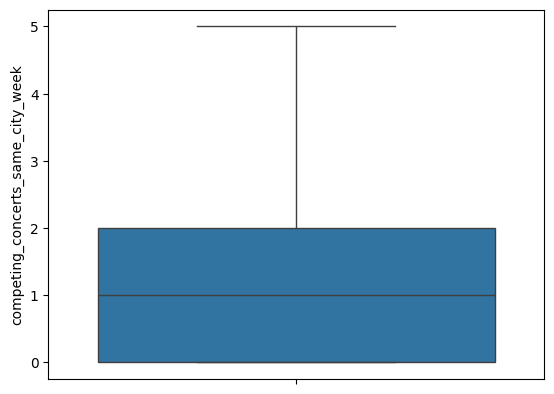

In [42]:
sns.boxplot(data=x_train['competing_concerts_same_city_week'])
plt.xticks(rotation=90)
plt.show()

# Outlier Treatment

After evaluating the identified outliers using IQR-based analysis and boxplot visualization, most observations were retained because they represent genuine business variations (e.g., highly popular artists, large-capacity venues) or are a natural consequence of frequency encoding. Removing or modifying these values would result in the loss of meaningful business information.

The feature competing_concerts_same_city_week was treated differently. Observations exceeding the training-set-derived upper fence (5) were winsorized (clipped) rather than removed. Since only a small proportion of observations exceeded this threshold, clipping helped reduce the influence of extreme competition levels while preserving all observations for model training.

In [43]:
#checking skewness of the continous values
continuous_cols = ['spotify_popularity','followers_millions','monthly_listeners_millions','total_streams_billions',
                   'years_active','instagram_followers_millions','tiktok_followers_millions','youtube_subscribers_millions',
                   'twitter_followers_millions','facebook_followers_millions','google_trend_index','festival_tier',
                   'num_artists_on_lineup','capacity','distance_from_airport_km','month','quarter','year',
                   'competing_concerts_same_city_week']

In [44]:
x_train[continuous_cols].skew().sort_values(ascending=False)

twitter_followers_millions           1.802800
tiktok_followers_millions            1.728650
facebook_followers_millions          1.593279
total_streams_billions               1.571938
instagram_followers_millions         1.512800
youtube_subscribers_millions         1.480714
monthly_listeners_millions           1.360652
competing_concerts_same_city_week    1.252381
followers_millions                   1.221403
capacity                             1.130091
distance_from_airport_km             0.814095
num_artists_on_lineup                0.583563
spotify_popularity                   0.473036
google_trend_index                   0.415093
festival_tier                        0.068669
years_active                         0.043911
month                               -0.082940
quarter                             -0.128117
year                                -0.205147
dtype: float64

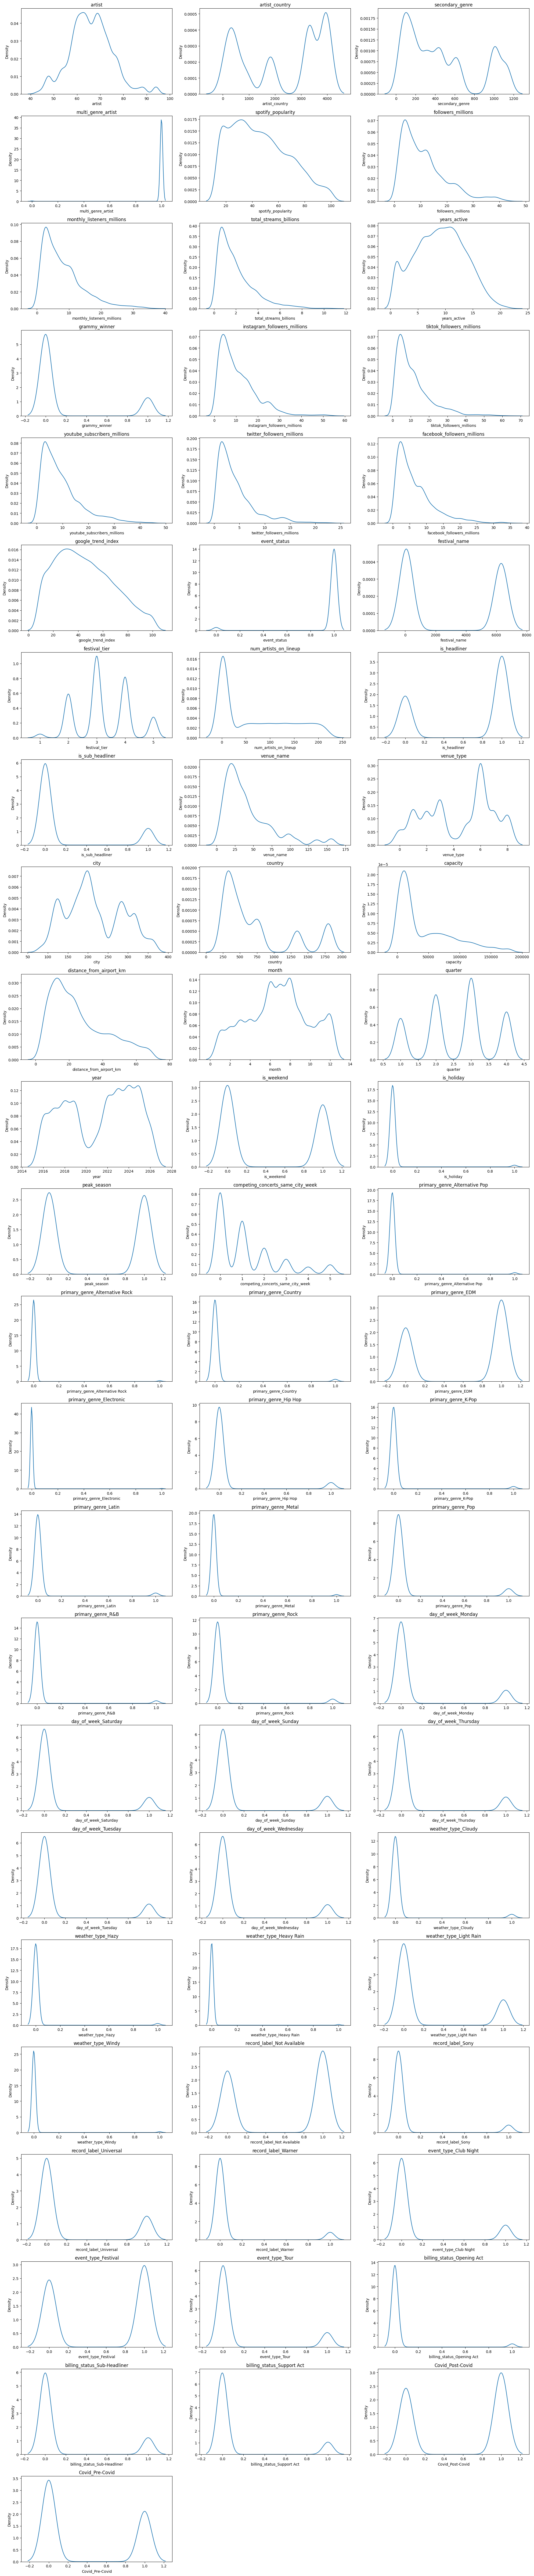

In [45]:
n_cols = 3
n_rows = math.ceil(len(x_train.columns) / n_cols)
plt.figure(figsize=(20, n_rows*4))
for i, col in enumerate(x_train.columns):
    plt.subplot(n_rows, n_cols, i+1)
    sns.kdeplot(x=x_train[col])
    plt.title(col)
plt.tight_layout()
plt.show()

# Skewness Analysis

Skewness was evaluated for all continuous numerical features after outlier treatment. Several popularity-related variables (e.g., social media followers, monthly listeners, and total streams) exhibited moderate to high positive skewness. However, these distributions accurately reflect real-world business characteristics, where a small number of globally recognized artists naturally have substantially larger audiences than most performers.

Since these observations represent genuine market behavior rather than anomalies, no additional transformations (such as logarithmic transformations) were applied. Tree-based models used later in the analysis are inherently robust to skewed feature distributions, while StandardScaler was applied prior to training regression models to place numerical variables on a comparable scale.

Target Skewness : 0.7501445800871448


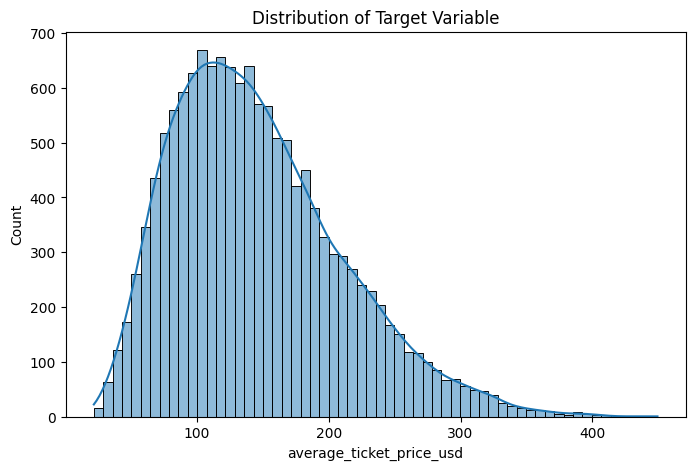

In [46]:
print("Target Skewness :", y_train.skew())

plt.figure(figsize=(8,5))
sns.histplot(y_train, kde=True)
plt.title("Distribution of Target Variable")
plt.show()

The target variable (average_ticket_price_usd) exhibited moderate positive skewness (0.75). Since the skewness was not severe (>1), no logarithmic transformation was applied. The original target variable was retained to preserve interpretability of predictions in the original ticket price units. The validity of this decision was further assessed during model evaluation by examining the residual distribution and regression assumptions.

# Scaling and Model Building

In [47]:
ss = StandardScaler()

In [48]:
x_train = pd.DataFrame(ss.fit_transform(x_train),columns=x_train.columns,index=x_train.index)
x_test = pd.DataFrame(ss.transform(x_test),columns=x_test.columns,index=x_test.index)

In [49]:
x_train.describe().round(2)

,artist,artist_country,secondary_genre,multi_genre_artist,spotify_popularity,followers_millions,monthly_listeners_millions,total_streams_billions,years_active,grammy_winner,...,record_label_Universal,record_label_Warner,event_type_Club Night,event_type_Festival,event_type_Tour,billing_status_Opening Act,billing_status_Sub-Headliner,billing_status_Support Act,Covid_Post-Covid,Covid_Pre-Covid
count,14000.00,14000.00,14000.00,14000.00,14000.00,14000.00,14000.00,14000.00,14000.00,14000.00,...,14000.00,14000.0,14000.00,14000.00,14000.00,14000.00,14000.00,14000.00,14000.00,14000.00
mean,-0.00,-0.00,0.00,0.00,-0.00,0.00,0.00,-0.00,-0.00,0.00,...,-0.00,0.0,0.00,0.00,-0.00,-0.00,0.00,-0.00,-0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,...,1.00,1.0,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-2.53,-1.47,-1.15,-14.64,-1.41,-1.31,-1.26,-1.18,-1.78,-0.47,...,-0.54,-0.3,-0.42,-1.10,-0.42,-0.20,-0.45,-0.39,-1.11,-0.79
25%,-0.67,-1.18,-0.91,0.07,-0.82,-0.79,-0.78,-0.74,-0.67,-0.47,...,-0.54,-0.3,-0.42,-1.10,-0.42,-0.20,-0.45,-0.39,-1.11,-0.79
50%,-0.12,0.68,-0.27,0.07,-0.14,-0.25,-0.26,-0.28,-0.00,-0.47,...,-0.54,-0.3,-0.42,0.91,-0.42,-0.20,-0.45,-0.39,0.90,-0.79
75%,0.54,1.10,0.49,0.07,0.73,0.48,0.46,0.44,0.66,-0.47,...,-0.54,-0.3,-0.42,0.91,-0.42,-0.20,-0.45,-0.39,0.90,1.27
max,3.07,1.10,1.85,0.07,2.46,3.98,4.54,5.51,2.88,2.12,...,1.86,3.3,2.36,0.91,2.37,5.02,2.21,2.58,0.90,1.27


In [50]:
lr = LinearRegression()

In [51]:
lr.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [52]:
print("Coef: ", lr.coef_)
print("Intercept: ", lr.intercept_)

Coef:  [ 4.24420223e-01 -2.42550909e+00 -6.28661504e-01  1.21955856e-01
  1.55126164e+01  8.98276559e+00 -2.95426374e-01 -2.88543560e-01
  2.44258133e+00  2.19427740e+00 -1.93219075e-01 -3.45465883e-01
  2.88715600e+00  6.24531737e-01  7.35856206e-01  1.14381734e+00
 -5.25701936e-01  1.07141686e+03  1.25110455e+01 -5.64456630e-01
  9.54548688e+00 -8.23697444e-01 -1.50339226e+00 -4.52544541e-01
  1.07785500e+00  1.64085520e+01  9.16415299e-01  2.45743348e-01
 -6.61123164e+00  6.58350314e+00  2.30217825e+01  3.91987320e+00
 -2.36447707e-01  7.45660470e+00  1.59528892e+00  1.37553566e-01
 -2.40050443e-01  2.16882375e-01 -6.95873523e-01  2.12047032e-01
  2.29190460e+00 -6.53733221e-01  6.79581705e-01  1.24289330e+00
  9.66886087e-02  1.89776316e-01  6.26896227e-01 -1.47433410e+00
  3.06468209e-02  1.27438410e-01 -7.81897387e-01 -1.43891713e+00
 -1.87527511e+00 -3.59877489e-01 -1.59626041e+00  1.05828619e-01
 -4.35623569e-01  1.07609967e-01 -2.27313527e+00 -6.90744873e-01
 -2.37780135e-01 -

In [53]:
y_pred = lr.predict(x_test)
print(y_pred)

[219.30601736 109.09533361  85.64005132 ...  67.7091664  176.77853655
  45.55436868]


In [54]:
mse = mean_squared_error(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
mape = mean_absolute_percentage_error(y_test,y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,y_pred)

In [55]:
#adj r2
n = len(y_test)
p = x_test.shape[1]
adj_r2 = 1 - (((1-r2)*(n-1)/(n-p-1)))

In [56]:
baseline_results = pd.DataFrame({"Metric": ["R²", "Adjusted R²", "MAE", "RMSE", "MAPE"],
    "Value": [ r2,adj_r2,mae,rmse,mape]})
baseline_results

,Metric,Value
0,R²,0.721445
1,Adjusted R²,0.718156
2,MAE,26.106080
3,RMSE,33.968120
4,MAPE,0.206330


## Baseline Multiple Linear Regression

A Multiple Linear Regression model was selected as the baseline regression algorithm to establish an initial benchmark for predicting average ticket prices. Since the target variable is continuous, Linear Regression provides an interpretable starting point for understanding the relationship between the predictor variables and ticket prices. This baseline model also serves as a reference against which more advanced models and regularization techniques will be compared.

## Baseline Model Performance

The baseline model achieved an R² Score of 72.14%, indicating that approximately 72% of the variation in average ticket prices can be explained by the selected predictor variables. The Adjusted R² (72.06%) is nearly identical to the R² score, suggesting that the model is not artificially benefiting from unnecessary predictors and that the engineered features contribute meaningful information.

Although the baseline model demonstrates promising predictive performance, Linear Regression relies on several statistical assumptions. Therefore, the next step is to evaluate these assumptions through residual diagnostics and multicollinearity analysis before applying feature selection, regularization techniques, and more advanced machine learning models.

In [57]:
x_train_sm = sm.add_constant(x_train)

In [58]:
model = sm.OLS(y_train,x_train_sm).fit()

In [59]:
print(model.summary())

                               OLS Regression Results                               
Dep. Variable:     average_ticket_price_usd   R-squared:                       0.718
Model:                                  OLS   Adj. R-squared:                  0.717
Method:                       Least Squares   F-statistic:                     530.2
Date:                      Sat, 11 Jul 2026   Prob (F-statistic):               0.00
Time:                              16:48:25   Log-Likelihood:                -69263.
No. Observations:                     14000   AIC:                         1.387e+05
Df Residuals:                         13932   BIC:                         1.392e+05
Df Model:                                67                                         
Covariance Type:                  nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------

# OLS Regression Summary

The Ordinary Least Squares (OLS) summary indicates that the baseline regression model is statistically significant (F-test p-value < 0.001), suggesting that the predictor variables collectively explain a substantial proportion of the variation in average ticket prices.

The model achieved an R² of 0.718 and an Adjusted R² of 0.717, indicating that approximately 72% of the variance in ticket prices is explained while maintaining similar explanatory power after adjusting for the number of predictors.

The Durbin-Watson statistic (≈2.0) suggests that the residuals are approximately independent, satisfying one of the key assumptions of Linear Regression.

However, the very large condition number and extremely small eigenvalue indicate the presence of potential multicollinearity among the predictor variables. Since OLS diagnostics alone cannot identify which predictors are responsible, Variance Inflation Factor (VIF) analysis is performed in the next step to quantify multicollinearity and identify redundant predictors. Although one-hot encoding was performed using drop='first' to avoid the dummy variable trap, the OLS summary reported a high condition number, suggesting the presence of multicollinearity arising from relationships among the predictor variables rather than from the encoding process itself. Therefore, Variance Inflation Factor (VIF) analysis was performed to identify predictors contributing to multicollinearity.

In [60]:
#residual analysis
residuals = y_test - y_pred
print(residuals)

10650   -75.246017
2041     -5.055334
8668     21.029949
1114      3.538219
13902   -43.742535
           ...    
4464     57.683062
15656    12.039138
19146     6.170834
10567   -38.708537
9165     -0.054369
Name: average_ticket_price_usd, Length: 6000, dtype: float64


<Axes: xlabel='average_ticket_price_usd', ylabel='Density'>

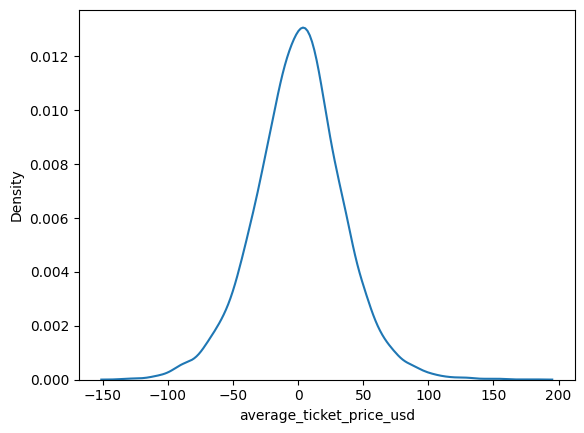

In [61]:
sns.kdeplot(residuals)

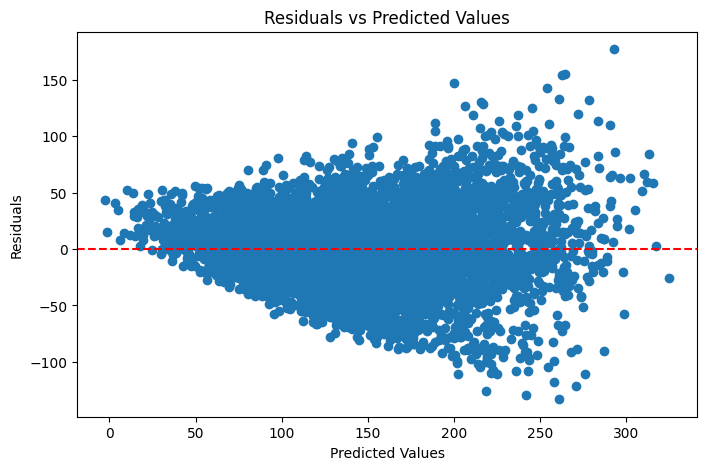

In [62]:
plt.figure(figsize=(8,5))
plt.scatter(y_pred, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Values")
plt.show()

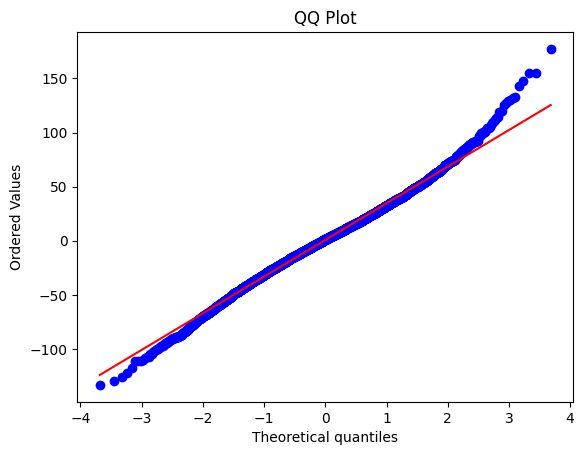

In [63]:
stats.probplot(residuals, dist='norm', plot=plt)
plt.title("QQ Plot")
plt.show()

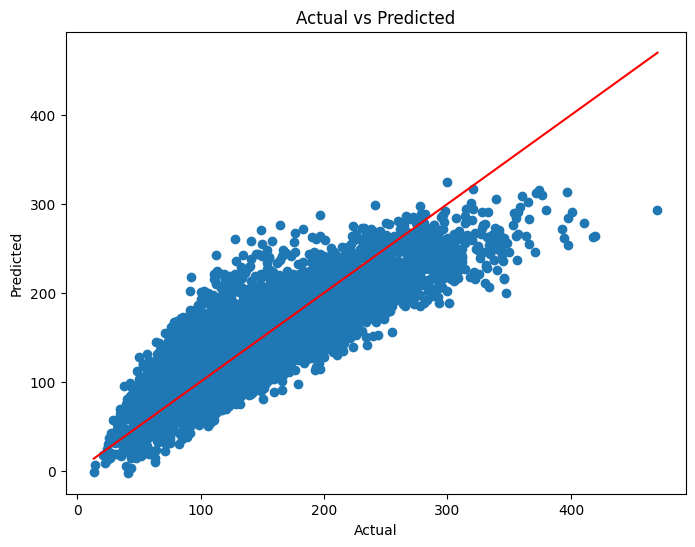

In [64]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red'
)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

# Residual Analysis

Residual diagnostics were performed to evaluate the assumptions of the baseline Linear Regression model. The residual distribution was approximately centered around zero and exhibited a near-normal bell-shaped pattern, suggesting that the normality assumption is reasonably satisfied. Minor deviations in the tails were observed but are expected in real-world pricing data.

The residuals versus predicted values plot showed a slight increase in residual variance as the predicted ticket price increased, indicating mild heteroscedasticity. This suggests that prediction errors are slightly larger for higher-priced events compared to lower-priced events.

The Actual versus Predicted plot demonstrated a strong positive linear relationship, indicating that the model successfully captures the overall trend in ticket prices. However, the model showed a tendency to slightly underpredict some of the highest-priced events, highlighting opportunities for improvement using regularization techniques and non-linear machine learning models.

# Variance Inflation Factor (VIF)

Before proceeding with feature selection and regularization, multicollinearity was evaluated using the Variance Inflation Factor (VIF). While the OLS summary indicated a high condition number, it does not identify which predictors are responsible for multicollinearity. VIF provides a feature-wise measure of how much the variance of a regression coefficient is inflated due to linear relationships with other predictors.

In this project, features with VIF greater than 5 were considered candidates for further investigation, while values greater than 10 indicate severe multicollinearity according to commonly accepted guidelines. Features were not removed solely based on VIF; business relevance and model performance were also considered before making feature selection decisions.

In [65]:
vif = pd.DataFrame()
vif['VIF'] = [variance_inflation_factor(x_train.values,i) for i in range (x_train.shape[1])]
vif

C:\Users\91875\AppData\Roaming\Python\Python310\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,VIF
0,1.169828
1,1.745045
2,1.424271
3,1.443681
4,16.747461
...,...
65,inf
66,inf
67,inf
68,6.872363


In [66]:
vif = vif.sort_values("VIF",ascending=False)
vif

,VIF
52,inf
47,inf
67,inf
31,inf
20,inf
...,...
54,1.023808
53,1.021645
57,1.008564
55,1.008002


In [67]:
x_train.nunique().sort_values()

multi_genre_artist                  2
grammy_winner                       2
is_headliner                        2
event_status                        2
is_weekend                          2
                                ...  
instagram_followers_millions      478
tiktok_followers_millions         532
distance_from_airport_km          671
total_streams_billions            831
capacity                        12121
Length: 70, dtype: int64

In [68]:
vif["Feature"] = x_train.columns
vif.sort_values("VIF", ascending=False)

,VIF,Feature
52,inf,artist
47,inf,artist_country
67,inf,secondary_genre
31,inf,multi_genre_artist
20,inf,spotify_popularity
...,...,...
54,1.023808,billing_status_Opening Act
53,1.021645,billing_status_Sub-Headliner
57,1.008564,billing_status_Support Act
55,1.008002,Covid_Post-Covid


In [69]:
x_train[['is_sub_headliner', 'billing_status_Sub-Headliner','is_headliner']].head(20)

,is_sub_headliner,billing_status_Sub-Headliner,is_headliner
17218,-0.452111,-0.452111,0.715001
15188,-0.452111,-0.452111,0.715001
11295,-0.452111,-0.452111,0.715001
19772,-0.452111,-0.452111,-1.398600
13072,-0.452111,-0.452111,0.715001
19921,-0.452111,-0.452111,0.715001
6649,-0.452111,-0.452111,0.715001
11581,2.211844,2.211844,-1.398600
8076,-0.452111,-0.452111,0.715001
10911,2.211844,2.211844,-1.398600


In [70]:
(x_train['is_sub_headliner'] ==
 x_train['billing_status_Sub-Headliner']).all()

np.True_

In [71]:
x_train.drop(
    columns=['is_sub_headliner','is_headliner'],
    inplace=True
)

x_test.drop(
    columns=['is_sub_headliner','is_headliner'],
    inplace=True
)

In [72]:
duplicate_pairs = []

for i, col1 in enumerate(x_train.columns):
    for col2 in x_train.columns[i+1:]:
        if x_train[col1].equals(x_train[col2]):
            duplicate_pairs.append((col1, col2))

duplicate_pairs

[]

In [73]:
vif = pd.DataFrame()
vif['VIF'] = [variance_inflation_factor(x_train.values,i) for i in range (x_train.shape[1])]
vif

C:\Users\91875\AppData\Roaming\Python\Python310\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,VIF
0,1.169828
1,1.745045
2,1.424271
3,1.443681
4,16.747461
...,...
63,1.095656
64,1.196320
65,1.333474
66,6.872363


In [74]:
vif["Feature"] = x_train.columns
vif.sort_values("VIF", ascending=False)

,VIF,Feature
48,inf,day_of_week_Thursday
49,inf,day_of_week_Tuesday
50,inf,day_of_week_Wednesday
29,inf,is_weekend
45,inf,day_of_week_Monday
...,...,...
52,1.023808,weather_type_Hazy
51,1.021645,weather_type_Cloudy
55,1.008564,weather_type_Windy
53,1.008002,weather_type_Heavy Rain


In [75]:
pd.crosstab(x_train['month'],x_train['quarter'])

quarter,-1.576609,-0.576540,0.423529,1.423598
month,,,,
-1.889870,731,0,0,0
-1.563830,768,0,0,0
-1.237789,953,0,0,0
-0.911749,0,953,0,0
-0.585708,0,987,0,0
-0.259668,0,1923,0,0
0.066373,0,0,1755,0
0.392413,0,0,2017,0
0.718453,0,0,1075,0


In [76]:
pd.crosstab(x_train['festival_name'], x_train['event_type_Festival'])

event_type_Festival,-1.102198,0.907278
festival_name,,
-0.914840,0,46
-0.914197,0,48
-0.912590,0,53
-0.912269,0,270
-0.911947,0,55
-0.911304,0,57
-0.910983,0,58
-0.910661,0,118
-0.910340,0,120


In [77]:
corr = x_train.corr().abs()
high_corr = (corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack().sort_values(ascending=False))
high_corr.head(20)

festival_name                 event_type_Festival             0.999998
followers_millions            monthly_listeners_millions      0.971875
month                         quarter                         0.964262
spotify_popularity            google_trend_index              0.942822
followers_millions            instagram_followers_millions    0.935262
monthly_listeners_millions    total_streams_billions          0.924364
followers_millions            youtube_subscribers_millions    0.923797
monthly_listeners_millions    instagram_followers_millions    0.906927
followers_millions            facebook_followers_millions     0.905644
year                          Covid_Post-Covid                0.899505
followers_millions            total_streams_billions          0.898901
monthly_listeners_millions    facebook_followers_millions     0.897692
year                          Covid_Pre-Covid                 0.895338
monthly_listeners_millions    youtube_subscribers_millions    0.882737
Covid_

In [78]:
x_train.drop(columns=['quarter','event_type_Festival','is_weekend'],inplace=True)
x_test.drop(columns=['quarter','event_type_Festival','is_weekend'],inplace=True)

In [79]:
vif = pd.DataFrame()
vif['VIF'] = [variance_inflation_factor(x_train.values,i) for i in range (x_train.shape[1])]
vif

,VIF
0,1.169563
1,1.744810
2,1.424224
3,1.443306
4,16.742180
...,...
60,1.095543
61,1.196042
62,1.332781
63,6.869207


In [80]:
vif['Features'] = x_train.columns
vif.sort_values("VIF",ascending=False)

,VIF,Features
5,55.844034,followers_millions
6,29.354660,monthly_listeners_millions
4,16.742180,spotify_popularity
34,13.622486,primary_genre_EDM
10,10.592628,instagram_followers_millions
...,...,...
50,1.023470,weather_type_Hazy
49,1.021632,weather_type_Cloudy
53,1.008389,weather_type_Windy
51,1.007812,weather_type_Heavy Rain


In [81]:
x_train[['primary_genre_EDM','festival_name','spotify_popularity','followers_millions']].corr()

,primary_genre_EDM,festival_name,spotify_popularity,followers_millions
primary_genre_EDM,1.000000,-0.001932,-0.297305,-0.388324
festival_name,-0.001932,1.000000,0.001372,0.009779
spotify_popularity,-0.297305,0.001372,1.000000,0.848665
followers_millions,-0.388324,0.009779,0.848665,1.000000


# Variance Inflation Factor (VIF) Analysis

Variance Inflation Factor (VIF) analysis was performed to assess multicollinearity among the predictor variables. The initial VIF assessment revealed several infinite VIF values, indicating perfect multicollinearity within the feature set. Further investigation showed that some engineered features were deterministic transformations or duplicate representations of existing variables. For example, quarter was derived directly from month, is_weekend was completely determined by day_of_week, and event_type_Festival duplicated information already captured by festival_name. These redundant features were removed before recomputing VIF.

After eliminating these deterministic relationships, the remaining predictors exhibited finite VIF values. Higher VIF values were primarily observed among artist popularity metrics such as followers, monthly listeners, Spotify popularity, and Instagram followers. These variables naturally measure related aspects of an artist's popularity and audience reach, making moderate to high multicollinearity expected from a business perspective rather than indicative of poor data quality.

Rather than removing these variables solely to reduce VIF, they were retained because each represents meaningful business information. The remaining multicollinearity will be addressed using regularization techniques (Ridge, Lasso, and ElasticNet Regression), which are specifically designed to handle correlated predictors while maintaining predictive performance.

During the multicollinearity analysis, two additional redundant variables (is_headliner and is_sub_headliner) were identified. These variables contained the same information already represented by the one-hot encoded billing status features (billing_status_Sub-Headliner and related billing indicators). Since they were perfect duplicates, they were removed to eliminate redundant predictors and avoid perfect multicollinearity.

In [82]:
lr = LinearRegression()

In [83]:
lr.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [84]:
y_pred = lr.predict(x_test)
print(y_pred)

[221.32894243 109.11651853  84.25302443 ...  63.00343445 179.35176148
  47.73791687]


In [85]:
mse = mean_squared_error(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
mape = mean_absolute_percentage_error(y_test,y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,y_pred)

In [86]:
#adj r2
n = len(y_test)
p = x_test.shape[1]
adj_r2 = 1 - (((1-r2)*(n-1)/(n-p-1)))

In [87]:
baseline_results = pd.DataFrame({"Metric": ["R²", "Adjusted R²", "MAE", "RMSE", "MAPE"],
    "Value": [ r2,adj_r2,mae,rmse,mape]})
baseline_results

,Metric,Value
0,R²,0.720602
1,Adjusted R²,0.717541
2,MAE,26.156611
3,RMSE,34.019519
4,MAPE,0.207219


In [88]:
x_train_sm = sm.add_constant(x_train)

In [89]:
model = sm.OLS(y_train,x_train_sm).fit()

In [90]:
print(model.summary())

                               OLS Regression Results                               
Dep. Variable:     average_ticket_price_usd   R-squared:                       0.716
Model:                                  OLS   Adj. R-squared:                  0.715
Method:                       Least Squares   F-statistic:                     541.7
Date:                      Sat, 11 Jul 2026   Prob (F-statistic):               0.00
Time:                              16:48:51   Log-Likelihood:                -69308.
No. Observations:                     14000   AIC:                         1.387e+05
Df Residuals:                         13934   BIC:                         1.392e+05
Df Model:                                65                                         
Covariance Type:                  nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------

[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.


# Post-VIF Model Interpretation

After removing deterministic and redundant predictors identified during the VIF analysis, the Linear Regression model was refitted using the refined feature set. The updated OLS summary showed a dramatic reduction in the condition number (from approximately 1.58 × 10¹⁶ to 28.5), indicating that severe multicollinearity had been successfully addressed while maintaining almost identical predictive performance.

The model continued to explain approximately 72% of the variance in ticket prices, demonstrating that the removed predictors contributed little additional predictive information and were largely redundant. This confirms that the VIF-based feature refinement improved numerical stability without materially affecting model accuracy.

# Regularization Techniques

Although the baseline Linear Regression model demonstrated good predictive performance, VIF analysis revealed moderate multicollinearity among several artist popularity features. High multicollinearity can increase the variance of regression coefficients and reduce model stability, even when predictive performance remains satisfactory.

To address this limitation, regularization techniques including Ridge Regression, Lasso Regression, and ElasticNet Regression were implemented. These models penalize large regression coefficients, thereby improving model generalization while mitigating the impact of correlated predictors.

The objective of this stage is to compare the predictive performance of these regularized models against the baseline Linear Regression model and evaluate their effectiveness in handling multicollinearity.

In [91]:
ridge = Ridge(random_state=42)

In [92]:
ridge.fit(x_train,y_train)

,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,42


In [93]:
ridge_pred = ridge.predict(x_test)

In [94]:
ridge_mae = mean_absolute_error(y_test, ridge_pred)
ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))
ridge_mape = mean_absolute_percentage_error(y_test, ridge_pred)
ridge_r2 = r2_score(y_test, ridge_pred)
print("R² :", ridge_r2)
print("MAE :", ridge_mae)
print("RMSE :", ridge_rmse)
print("MAPE :", ridge_mape)

R² : 0.7205981983468337
MAE : 26.156461697906334
RMSE : 34.01972149780697
MAPE : 0.20721550543491882


In [95]:
n = len(y_test)
p = x_test.shape[1]
ridge_adj_r2 = 1 - (((1-ridge_r2)*(n-1)/(n-p-1)))
print("Adjusted R² :", ridge_adj_r2)

Adjusted R² : 0.7175376797914822


In [96]:
param_grid = {'alpha':[0.001,0.01,1,10,50,100]}

In [97]:
grid = GridSearchCV(Ridge(),param_grid=param_grid,cv=5,scoring='r2')
grid.fit(x_train,y_train)

,estimator,Ridge()
,param_grid,"{'alpha': [0.001, 0.01, ...]}"
,scoring,'r2'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,alpha,10


In [98]:
grid.best_params_

{'alpha': 10}

In [99]:
ridge = Ridge(alpha=10,random_state=42)

In [100]:
ridge.fit(x_train,y_train)

,alpha,10
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,42


In [101]:
ridge_pred = ridge.predict(x_test)

In [102]:
ridge_mae = mean_absolute_error(y_test, ridge_pred)
ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))
ridge_mape = mean_absolute_percentage_error(y_test, ridge_pred)
ridge_r2 = r2_score(y_test, ridge_pred)
print("R² :", ridge_r2)
print("MAE :", ridge_mae)
print("RMSE :", ridge_rmse)
print("MAPE :", ridge_mape)

R² : 0.7205657619351513
MAE : 26.155225346010248
RMSE : 34.02169615520149
MAPE : 0.20718590455001185


In [103]:
n = len(y_test)
p = x_test.shape[1]
ridge_adj_r2 = 1 - (((1-ridge_r2)*(n-1)/(n-p-1)))
print("Adjusted R² :", ridge_adj_r2)

Adjusted R² : 0.7175048880770092


# Ridge Regression

Ridge Regression was implemented to reduce the impact of multicollinearity by applying L2 regularization, which penalizes large regression coefficients without eliminating predictor variables. Since the baseline Linear Regression model exhibited moderate multicollinearity among artist popularity metrics, Ridge Regression was evaluated to determine whether coefficient shrinkage would improve predictive performance and model stability.

Hyperparameter tuning was performed using GridSearchCV, which identified an optimal regularization parameter (α = 10). However, the tuned Ridge model achieved performance nearly identical to the baseline Linear Regression model, indicating that the original model was already relatively stable despite the presence of correlated predictors.

In [104]:
lasso = Lasso(random_state=42)

In [105]:
lasso.fit(x_train,y_train)

,alpha,1.0
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,42
,selection,'cyclic'


In [106]:
lasso_pred = lasso.predict(x_test)

In [107]:
lasso_mae = mean_absolute_error(y_test, lasso_pred)
lasso_rmse = np.sqrt(mean_squared_error(y_test, lasso_pred))
lasso_mape = mean_absolute_percentage_error(y_test, lasso_pred)
lasso_r2 = r2_score(y_test, lasso_pred)
print("R² :", lasso_r2)
print("MAE :", lasso_mae)
print("RMSE :", lasso_rmse)
print("MAPE :", lasso_mape)

R² : 0.7073854536289834
MAE : 26.61954998656047
RMSE : 34.814816363023674
MAPE : 0.20980987253565586


In [108]:
n = len(y_test)
p = x_test.shape[1]
lasso_adj_r2 = 1 - (((1-lasso_r2)*(n-1)/(n-p-1)))
print("Adjusted R² :", lasso_adj_r2)

Adjusted R² : 0.7041802049747676


In [109]:
param_grid = {'alpha':[0.001,0.01,1,10,50,100]}

In [110]:
grid = GridSearchCV(Lasso(),param_grid=param_grid,cv=5,scoring='r2')
grid.fit(x_train,y_train)

,estimator,Lasso()
,param_grid,"{'alpha': [0.001, 0.01, ...]}"
,scoring,'r2'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,alpha,0.01


In [111]:
grid.best_params_

{'alpha': 0.01}

In [112]:
lasso = Lasso(alpha=0.01,random_state=42)

In [113]:
lasso.fit(x_train,y_train)

,alpha,0.01
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,42
,selection,'cyclic'


In [114]:
lasso_pred = lasso.predict(x_test)

In [115]:
lasso_mae = mean_absolute_error(y_test, lasso_pred)
lasso_rmse = np.sqrt(mean_squared_error(y_test, lasso_pred))
lasso_mape = mean_absolute_percentage_error(y_test, lasso_pred)
lasso_r2 = r2_score(y_test, lasso_pred)
print("R² :", lasso_r2)
print("MAE :", lasso_mae)
print("RMSE :", lasso_rmse)
print("MAPE :", lasso_mape)

R² : 0.7206211767552081
MAE : 26.15306905372827
RMSE : 34.01832255348767
MAPE : 0.20718258957374072


In [116]:
n = len(y_test)
p = x_test.shape[1]
lasso_adj_r2 = 1 - (((1-lasso_r2)*(n-1)/(n-p-1)))
print("Adjusted R² :", lasso_adj_r2)

Adjusted R² : 0.7175609099013303


# Lasso Regression

Lasso Regression applies L1 regularization, which encourages sparse solutions by shrinking less important coefficients toward zero. In addition to mitigating multicollinearity, Lasso can perform automatic feature selection by eliminating predictors with minimal contribution to the model.

The default Lasso model showed a decline in predictive performance due to excessive regularization. Hyperparameter tuning using GridSearchCV identified an optimal regularization parameter (α = 0.01), resulting in model performance comparable to the baseline Linear Regression model. This indicates that only a small amount of regularization was appropriate for this dataset.

In [117]:
elastic = ElasticNet(random_state=42,l1_ratio=0.5)

In [118]:
elastic.fit(x_train,y_train)

,alpha,1.0
,l1_ratio,0.5
,fit_intercept,True
,precompute,False
,max_iter,1000
,copy_X,True
,tol,0.0001
,warm_start,False
,positive,False
,random_state,42
,selection,'cyclic'


In [119]:
elastic_pred = elastic.predict(x_test)

In [120]:
elastic_mae = mean_absolute_error(y_test, elastic_pred)
elastic_rmse = np.sqrt(mean_squared_error(y_test, elastic_pred))
elastic_mape = mean_absolute_percentage_error(y_test, elastic_pred)
elastic_r2 = r2_score(y_test, elastic_pred)
print("R² :", elastic_r2)
print("MAE :", elastic_mae)
print("RMSE :", elastic_rmse)
print("MAPE :", elastic_mape)

R² : 0.662534206632428
MAE : 28.427958248678692
RMSE : 37.387896500298176
MAPE : 0.22759245976583475


In [121]:
n = len(y_test)
p = x_test.shape[1]
elastic_adj_r2 = 1 - (((1-elastic_r2)*(n-1)/(n-p-1)))
print("Adjusted R² :", elastic_adj_r2)

Adjusted R² : 0.6588376652490623


In [122]:
param_grid = {'alpha':[0.001,0.01,1,10,50,100]}

In [123]:
grid = GridSearchCV(ElasticNet(),param_grid=param_grid,cv=5,scoring='r2')
grid.fit(x_train,y_train)

,estimator,ElasticNet()
,param_grid,"{'alpha': [0.001, 0.01, ...]}"
,scoring,'r2'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,alpha,0.001


In [124]:
grid.best_params_

{'alpha': 0.001}

In [125]:
elastic = ElasticNet(alpha=0.001,random_state=42,l1_ratio=0.5)

In [126]:
elastic.fit(x_train,y_train)

,alpha,0.001
,l1_ratio,0.5
,fit_intercept,True
,precompute,False
,max_iter,1000
,copy_X,True
,tol,0.0001
,warm_start,False
,positive,False
,random_state,42
,selection,'cyclic'


In [127]:
elastic_pred = elastic.predict(x_test)

In [128]:
elastic_mae = mean_absolute_error(y_test, elastic_pred)
elastic_rmse = np.sqrt(mean_squared_error(y_test, elastic_pred))
elastic_mape = mean_absolute_percentage_error(y_test, elastic_pred)
elastic_r2 = r2_score(y_test, elastic_pred)
print("R² :", elastic_r2)
print("MAE :", elastic_mae)
print("RMSE :", elastic_rmse)
print("MAPE :", elastic_mape)

R² : 0.7205787309907313
MAE : 26.155456560431098
RMSE : 34.02090664137687
MAPE : 0.20719405473528907


In [129]:
n = len(y_test)
p = x_test.shape[1]
elastic_adj_r2 = 1 - (((1-elastic_r2)*(n-1)/(n-p-1)))
print("Adjusted R² :", elastic_adj_r2)

Adjusted R² : 0.7175179991933598


# ElasticNet Regression

ElasticNet Regression combines both L1 (Lasso) and L2 (Ridge) regularization penalties, providing a balance between coefficient shrinkage and automatic feature selection. This approach is particularly useful when predictor variables exhibit multicollinearity while also containing redundant features.

Hyperparameter tuning using GridSearchCV identified an optimal regularization parameter (α = 0.001). Similar to Ridge and Lasso Regression, the tuned ElasticNet model achieved predictive performance nearly identical to the baseline Linear Regression model. This indicates that the original feature engineering pipeline already produced a stable linear model and that additional regularization provided only marginal benefits.

# Comparison of Regularization Techniques

Ridge, Lasso, and ElasticNet Regression were evaluated to determine whether regularization could improve the baseline Linear Regression model by reducing the effects of multicollinearity. Although VIF analysis identified correlated predictor variables, all three regularized models achieved performance very similar to the baseline model after hyperparameter tuning.

These results suggest that the baseline Linear Regression model was already well-generalized and that multicollinearity had only a limited impact on predictive accuracy. Consequently, regularization primarily improved model robustness rather than overall predictive performance. This also demonstrates that feature engineering and preprocessing were effective in producing a stable regression model.

# Random Forest Regression

While Linear Regression and regularization techniques model only linear relationships, ticket pricing is influenced by complex interactions among artist popularity, festival characteristics, venue capacity, seasonality, and event-specific factors. Random Forest Regression was therefore implemented to capture these non-linear relationships without requiring strict statistical assumptions such as linearity or multicollinearity.

As an ensemble learning algorithm, Random Forest builds multiple decision trees on different bootstrap samples and combines their predictions, reducing variance while improving generalization. The objective is to compare its predictive performance against the previously developed linear models.

In [130]:
rf = RandomForestRegressor(random_state=42,n_jobs=-1)

In [131]:
rf.fit(x_train,y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [132]:
rf_pred = rf.predict(x_test)

In [133]:
rf_r2 = r2_score(y_test, rf_pred)
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_mape = mean_absolute_percentage_error(y_test, rf_pred)
n = len(y_test)
p = x_test.shape[1]
rf_adj_r2 = 1 - (((1-rf_r2)*(n-1))/(n-p-1))
print("R² :", rf_r2)
print("Adjusted R² :", rf_adj_r2)
print("MAE :", rf_mae)
print("RMSE :", rf_rmse)
print("MAPE :", rf_mape)

R² : 0.8450772995402244
Adjusted R² : 0.8433803033268968
MAE : 19.185310666666666
RMSE : 25.332245144349987
MAPE : 0.14222947041760653


In [134]:
param_grid = {'n_estimators': [100, 200],'max_depth': [10, 20],'min_samples_split': [2, 5],
              'min_samples_leaf': [1, 2],'ccp_alpha':[0.01,0.001,0]}

In [135]:
grid = RandomizedSearchCV(RandomForestRegressor(random_state=42),param_distributions=param_grid,n_iter=10,cv=3,
                          scoring='r2',n_jobs=4)
grid.fit(x_train,y_train)

,estimator,RandomForestR...ndom_state=42)
,param_distributions,"{'ccp_alpha': [0.01, 0.001, ...], 'max_depth': [10, 20], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], ...}"
,n_iter,10
,scoring,'r2'
,n_jobs,4
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [136]:
grid.best_params_

{'n_estimators': 200,
 'min_samples_split': 2,
 'min_samples_leaf': 1,
 'max_depth': 20,
 'ccp_alpha': 0.001}

In [137]:
rf = RandomForestRegressor(n_estimators=200,min_samples_split=2,min_samples_leaf=2,max_depth=20,
                           ccp_alpha=0.001,random_state=42,n_jobs=-1)

In [138]:
rf.fit(x_train,y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,20
,min_samples_split,2
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [139]:
rf_pred = rf.predict(x_test)

In [140]:
rf_r2 = r2_score(y_test, rf_pred)
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_mape = mean_absolute_percentage_error(y_test, rf_pred)
n = len(y_test)
p = x_test.shape[1]
rf_adj_r2 = 1 - (((1-rf_r2)*(n-1))/(n-p-1))
print("R² :", rf_r2)
print("Adjusted R² :", rf_adj_r2)
print("MAE :", rf_mae)
print("RMSE :", rf_rmse)
print("MAPE :", rf_mape)

R² : 0.8458621786392757
Adjusted R² : 0.8441737798545694
MAE : 19.150196615803132
RMSE : 25.267993758048313
MAPE : 0.14222010019097214


RandomizedSearchCV was performed to optimize the Random Forest hyperparameters. The tuned model selected 200 estimators, a maximum depth of 20, minimum samples split of 2, minimum samples leaf of 2, and cost-complexity pruning (ccp_alpha = 0.001).

The tuned model achieved only a marginal improvement over the baseline model (R² improved from 0.8451 to 0.8459). This indicates that the default Random Forest configuration was already well-suited to the dataset, and further hyperparameter optimization provided only incremental gains.

In [141]:
xgb = XGBRegressor(random_state=42,n_jobs=-1)

In [142]:
xgb.fit(x_train,y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [143]:
xgb_pred = xgb.predict(x_test)

In [144]:
xgb_r2 = r2_score(y_test, xgb_pred)
xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_mape = mean_absolute_percentage_error(y_test, xgb_pred)
n = len(y_test)
p = x_test.shape[1]
xgb_adj_r2 = 1 - (((1-xgb_r2)*(n-1))/(n-p-1))
print("R² :", xgb_r2)
print("Adjusted R² :", xgb_adj_r2)
print("MAE :", xgb_mae)
print("RMSE :", xgb_rmse)
print("MAPE :", xgb_mape)

R² : 0.8807682108033603
Adjusted R² : 0.8794621666008356
MAE : 16.91830212343534
RMSE : 22.223485974445094
MAPE : 0.12232349439908247


In [145]:
param_grid = {'n_estimators': [100, 200,300],'max_depth': [3,5,7,10],'learning_rate':[0.01,0.05,0.1,0.2],
              'subsample':[0.8,0.9,1.0],'colsample_bytree':[0.8,0.9,1.0]}

In [146]:
grid = RandomizedSearchCV(XGBRegressor(random_state=42),param_distributions=param_grid,n_iter=10,cv=3,
                          scoring='r2',n_jobs=4)
grid.fit(x_train,y_train)

,estimator,"XGBRegressor(...ree=None, ...)"
,param_distributions,"{'colsample_bytree': [0.8, 0.9, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200, ...], ...}"
,n_iter,10
,scoring,'r2'
,n_jobs,4
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [147]:
grid.best_params_

{'subsample': 0.9,
 'n_estimators': 300,
 'max_depth': 10,
 'learning_rate': 0.1,
 'colsample_bytree': 0.9}

In [148]:
xgb = XGBRegressor(subsample = 0.9,n_estimators=300,max_depth= 7,learning_rate=0.05,colsample_bytree=0.8,
                   random_state=42,n_jobs=-1)

In [149]:
xgb.fit(x_train,y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [150]:
xgb_pred = xgb.predict(x_test)

In [151]:
xgb_r2 = r2_score(y_test, xgb_pred)
xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_mape = mean_absolute_percentage_error(y_test, xgb_pred)
n = len(y_test)
p = x_test.shape[1]
xgb_adj_r2 = 1 - (((1-xgb_r2)*(n-1))/(n-p-1))
print("R² :", xgb_r2)
print("Adjusted R² :", xgb_adj_r2)
print("MAE :", xgb_mae)
print("RMSE :", xgb_rmse)
print("MAPE :", xgb_mape)

R² : 0.8956656428845411
Adjusted R² : 0.8945227825521338
MAE : 15.729937149416607
RMSE : 20.788819334233136
MAPE : 0.11188522146718564


# Feature Importance Analysis

Since XGBoost was selected as the final model based on its superior predictive performance, feature importance analysis was performed to identify the variables that contributed most to ticket price prediction.

Unlike Linear Regression, which assumes a linear relationship between predictors and the target variable, XGBoost captures complex non-linear interactions. Feature importance provides an estimate of how much each feature contributes to reducing prediction error across all trees in the ensemble.

This analysis improves the interpretability of the final model by highlighting the most influential business drivers of concert ticket prices.

In [152]:
importance = pd.DataFrame({'Feature': x_train.columns,'Importance': xgb.feature_importances_})
importance = importance.sort_values(by='Importance',ascending=False)
importance.head(20)

,Feature,Importance
4,spotify_popularity,0.166116
5,followers_millions,0.121638
62,billing_status_Support Act,0.081962
23,country,0.074609
60,billing_status_Opening Act,0.053764
61,billing_status_Sub-Headliner,0.049022
6,monthly_listeners_millions,0.047633
27,year,0.040729
18,festival_tier,0.039506
22,city,0.031950


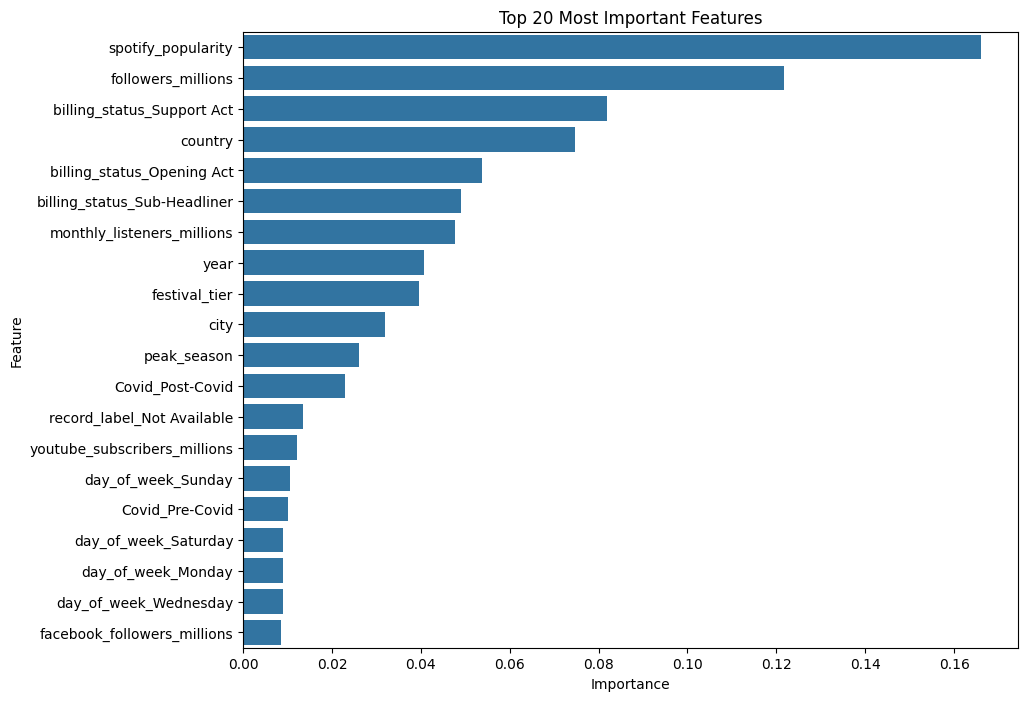

In [153]:
plt.figure(figsize=(10,8))
sns.barplot(data=importance.head(20),x='Importance',y='Feature')
plt.title("Top 20 Most Important Features")
plt.show()

# Feature Importance Interpretation

The feature importance analysis shows that artist popularity metrics (such as Spotify popularity, follower count, and monthly listeners), billing status, country, festival tier, and seasonal factors are among the strongest predictors of concert ticket prices. These findings align with domain expectations, as more popular artists, premium festivals, and favorable event timings generally command higher ticket prices.

An interesting observation is that several popularity-related variables ranked among the most influential features despite exhibiting relatively high multicollinearity during the Linear Regression analysis. While multicollinearity negatively affects coefficient estimation in linear models, tree-based ensemble models such as XGBoost are inherently more robust to correlated predictors. Consequently, these variables were retained for the tree-based models, allowing XGBoost to effectively leverage their predictive information and achieve the best overall performance.

In [154]:
model_comparison = pd.DataFrame({"Model": ["Linear Regression","Ridge Regression","Lasso Regression","ElasticNet",
                                           "Random Forest","XGBoost"],
                                 "R²":[r2,ridge_r2,lasso_r2,elastic_r2,rf_r2,xgb_r2],
                                 "Adjusted R²":[adj_r2,ridge_adj_r2,lasso_adj_r2,elastic_adj_r2,rf_adj_r2,xgb_adj_r2],
                                 "MAE":[mae,ridge_mae,lasso_mae,elastic_mae,rf_mae,xgb_mae],
                                 "RMSE":[rmse,ridge_rmse,lasso_rmse,elastic_rmse,rf_rmse,xgb_rmse],
                                 "MAPE":[mape,ridge_mape,lasso_mape,elastic_mape,rf_mape,xgb_mape]})
model_comparison = model_comparison.round(4)
model_comparison.style.highlight_max(subset=["R²", "Adjusted R²"],color="lightgreen").highlight_min(
    subset=["MAE", "RMSE", "MAPE"],color="lightgreen")

,Model,R²,Adjusted R²,MAE,RMSE,MAPE
0,Linear Regression,0.720600,0.717500,26.156600,34.019500,0.207200
1,Ridge Regression,0.720600,0.717500,26.155200,34.021700,0.207200
2,Lasso Regression,0.720600,0.717600,26.153100,34.018300,0.207200
3,ElasticNet,0.720600,0.717500,26.155500,34.020900,0.207200
4,Random Forest,0.845900,0.844200,19.150200,25.268000,0.142200
5,XGBoost,0.895700,0.894500,15.729900,20.788800,0.111900


# Final Model Comparison

Six regression models were developed and evaluated using R², Adjusted R², MAE, RMSE, and MAPE. Linear Regression and its regularized variants (Ridge, Lasso, and ElasticNet) established a strong baseline, achieving an R² of approximately 72%. However, their performance plateaued despite regularization, suggesting that the underlying relationships between the predictors and ticket prices were not purely linear.

Ensemble learning methods substantially improved predictive performance. The tuned Random Forest increased the R² to approximately 84.6%, while the tuned XGBoost model achieved the best overall performance with an R² of 89.6%, along with the lowest MAE, RMSE, and MAPE among all evaluated models.

Based on these results, the tuned XGBoost model was selected as the final production model because it consistently provided the highest predictive accuracy while maintaining good generalization on unseen test data.

In [155]:
train_r2 = xgb.score(x_train, y_train)
test_r2 = xgb.score(x_test, y_test)

In [156]:
print("Train R2",train_r2)
print("Test R2",test_r2)

Train R2 0.9639837587127595
Test R2 0.8956656428845411


# Train vs Test Performance

To assess model generalization, the R² score was evaluated on both the training and testing datasets. The tuned XGBoost model achieved a training R² of 96.40% and a testing R² of 89.57%. The difference of approximately 6.8 percentage points indicates a mild degree of overfitting, which is expected for a high-capacity ensemble model such as XGBoost.

Despite this gap, the model maintains strong predictive performance on unseen data, suggesting that it generalizes well and is suitable for deployment.

In [157]:
# ------------------------------------------------------------
# Create models folder
# ------------------------------------------------------------
os.makedirs("models", exist_ok=True)
# ------------------------------------------------------------
# Save Frequency Encoding Maps
# ------------------------------------------------------------
freq_maps = {"artist": artist_freq_map,"artist_country": artist_country_freq_map,"venue_name": venue_name_freq_map,
             "festival_name": festival_name_freq_map,"city": city_freq_map,"secondary_genre": secondary_genre_freq_map,
             "country": country_freq_map}
joblib.dump(freq_maps, "models/frequency_maps.pkl")
# ------------------------------------------------------------
# Save One Hot Encoder
# ------------------------------------------------------------
joblib.dump(ohe, "models/onehot_encoder.pkl")
# ------------------------------------------------------------
# Save Ordinal Encoder
# ------------------------------------------------------------
joblib.dump(oe, "models/venue_ordinal_encoder.pkl")
# ------------------------------------------------------------
# Save Standard Scaler
# ------------------------------------------------------------
joblib.dump(ss, "models/standard_scaler.pkl")
# ------------------------------------------------------------
# Save Outlier Clipping Bounds
# ------------------------------------------------------------
clipping_bounds = {"competing_concerts_same_city_week": {"lower_fence": lower_fence,"upper_fence": upper_fence}}
joblib.dump(clipping_bounds, "models/clipping_bounds.pkl")
# ------------------------------------------------------------
# Save Final Feature Column Order
# ------------------------------------------------------------
feature_columns = list(x_train.columns)
joblib.dump(feature_columns, "models/feature_columns.pkl")
# ------------------------------------------------------------
# Save Final XGBoost Model
# ------------------------------------------------------------
joblib.dump(xgb, "models/xgboost_model.pkl")
# ------------------------------------------------------------
# Verify Saved Files
# ------------------------------------------------------------
print("="*60)
print("Saved Model Artifacts")
print("="*60)
for file in sorted(os.listdir("models")):
    print(f"✓ {file}")
print("="*60)
print("All model artifacts saved successfully!")
print("="*60)

Saved Model Artifacts
✓ clipping_bounds.pkl
✓ feature_columns.pkl
✓ frequency_maps.pkl
✓ onehot_encoder.pkl
✓ standard_scaler.pkl
✓ venue_ordinal_encoder.pkl
✓ xgboost_model.pkl
All model artifacts saved successfully!


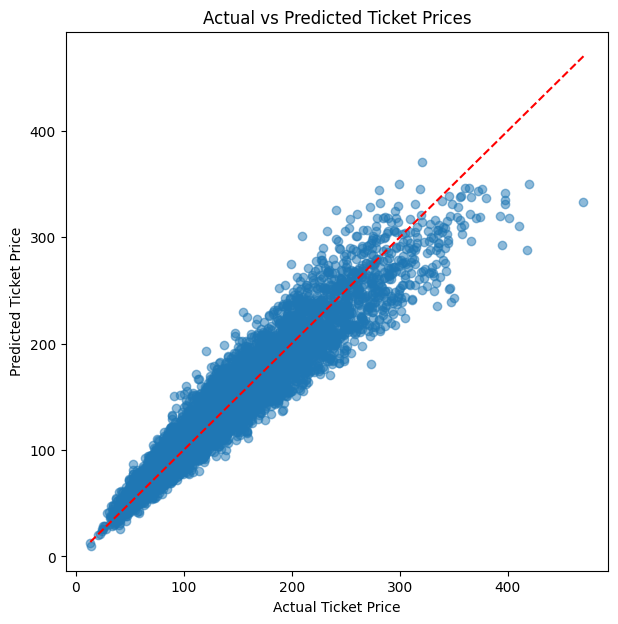

In [158]:
plt.figure(figsize=(7,7))

plt.scatter(y_test, xgb_pred, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Ticket Price")
plt.ylabel("Predicted Ticket Price")
plt.title("Actual vs Predicted Ticket Prices")
plt.show()